# Homework 10 — Gaussian Mixture Clustering of the World Happiness Report

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

The World Happiness Report scores 155 countries and breaks each score into six contributing factors. This notebook explores those factors, maps them, and then asks a Gaussian mixture model to group countries **by their factor profiles alone** — without ever showing it the happiness score — to see whether the groups it finds line up with the published ranking.

In [1]:
# Environment setup & imports
try:
    import plotly.express as px
except ImportError:
    !pip install -q plotly
    import plotly.express as px

import io
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, Normalizer, StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})
RANDOM_STATE = 42

## Steps 2–3: Download and Unpack the Data

In Colab the archive is fetched with `!wget` and unpacked with `!unzip`; the equivalent below uses `urllib` and `zipfile`, which works outside a Linux shell as well and reads the CSV straight from the archive.

In [2]:
URL = "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true"

request = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request, timeout=120) as response:
    archive = zipfile.ZipFile(io.BytesIO(response.read()))

print(f"Archive contains: {archive.namelist()}")

with archive.open("2017.csv") as handle:
    df = pd.read_csv(handle)

print(f"\nUsing 2017.csv: {df.shape[0]} countries, {df.shape[1]} columns")

Archive contains: ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']

Using 2017.csv: 155 countries, 12 columns


The archive holds five yearly reports. The 2017 file is the one this task is written around — it is the year whose column names (`Country`, `Happiness.Score`) match the code given in the assignment. The schema is not stable across years: 2015 has a `Region` column, 2019 renames everything, so mixing them would need a translation layer.

## Step 4: Structure and Summary Statistics

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    str    
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), str(1)
memory usage: 14.7 KB


In [4]:
print(f"Missing values: {df.isna().sum().sum()}, duplicated rows: {df.duplicated().sum()}\n")
df.describe().T.round(3)

Missing values: 0, duplicated rows: 0



,count,mean,std,min,25%,50%,75%,max
Happiness.Rank,155.0,78.000,44.889,1.000,39.500,78.000,116.500,155.000
Happiness.Score,155.0,5.354,1.131,2.693,4.506,5.279,6.102,7.537
Whisker.high,155.0,5.452,1.119,2.865,4.608,5.370,6.195,7.622
Whisker.low,155.0,5.256,1.145,2.521,4.375,5.193,6.007,7.480
Economy..GDP.per.Capita.,155.0,0.985,0.421,0.000,0.663,1.065,1.318,1.871
Family,155.0,1.189,0.287,0.000,1.043,1.254,1.414,1.611
Health..Life.Expectancy.,155.0,0.551,0.237,0.000,0.370,0.606,0.723,0.949
Freedom,155.0,0.409,0.150,0.000,0.304,0.437,0.517,0.658
Generosity,155.0,0.247,0.135,0.000,0.154,0.232,0.324,0.838
Trust..Government.Corruption.,155.0,0.123,0.102,0.000,0.057,0.090,0.153,0.464


All twelve columns are complete and numeric except `Country`. Three groups can be told apart by meaning, and the distinction decides what may be used for clustering:

- **the target** — `Happiness.Score` and its mirror `Happiness.Rank`, plus the confidence bounds `Whisker.high` / `Whisker.low`;
- **the six factors** — economy, family, health, freedom, generosity, trust;
- **`Dystopia.Residual`** — not a measurement at all, but the leftover that makes the decomposition add up exactly.

That last point is worth verifying rather than taking on faith.

In [5]:
FACTORS = [
    "Economy..GDP.per.Capita.",
    "Family",
    "Health..Life.Expectancy.",
    "Freedom",
    "Generosity",
    "Trust..Government.Corruption.",
]
SHORT_NAMES = ["Economy", "Family", "Health", "Freedom", "Generosity", "Trust"]

reconstructed = df[FACTORS].sum(axis=1) + df["Dystopia.Residual"]
deviation = (reconstructed - df["Happiness.Score"]).abs().max()

print("Happiness.Score == sum(six factors) + Dystopia.Residual")
print(f"Largest deviation across all 155 countries: {deviation:.2e}")
print(f"Identity holds within the published rounding: {deviation < 1e-3}")

Happiness.Score == sum(six factors) + Dystopia.Residual
Largest deviation across all 155 countries: 4.99e-04
Identity holds within the published rounding: True


The identity holds to $5 \cdot 10^{-4}$, which is the rounding of the published figures. So the score is the sum of its parts by construction — which means `Dystopia.Residual` must stay out of any model that predicts or groups by happiness, since it carries exactly the part of the score the six factors fail to explain.

## Step 5: Distributions of the Numeric Features

Histograms with a kernel density estimate, and a normal curve fitted to each feature's mean and standard deviation for reference.

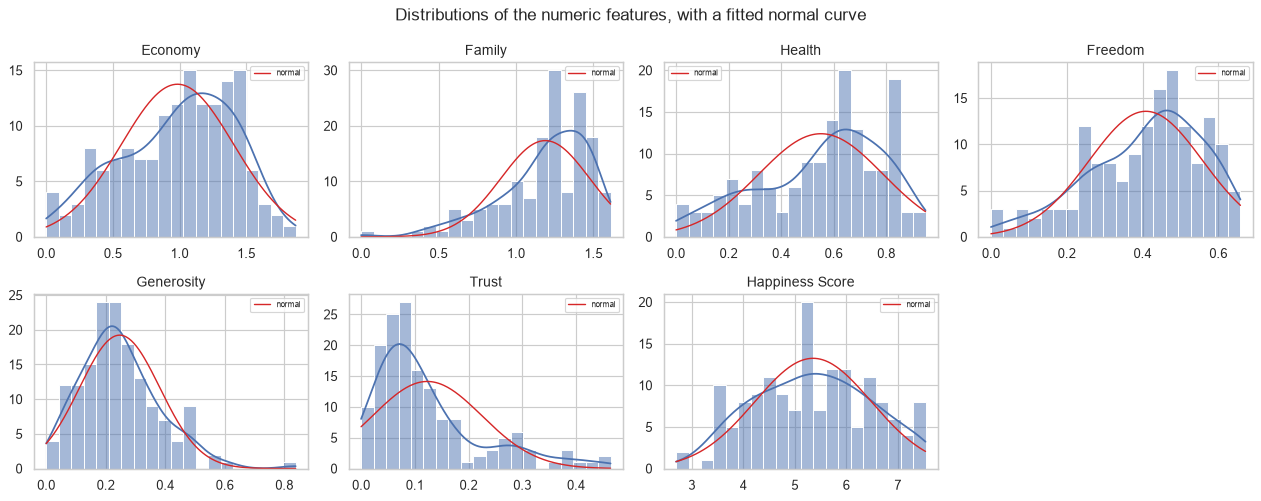

In [6]:
columns = FACTORS + ["Happiness.Score"]
titles = SHORT_NAMES + ["Happiness Score"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, column, title in zip(axes.ravel(), columns, titles):
    sns.histplot(df[column], kde=True, bins=20, ax=ax)

    grid = np.linspace(df[column].min(), df[column].max(), 200)
    normal = stats.norm.pdf(grid, df[column].mean(), df[column].std())
    ax.plot(grid, normal * len(df) * (df[column].max() - df[column].min()) / 20,
            color="tab:red", linewidth=1.2, label="normal")

    ax.set(title=title, xlabel="", ylabel="")
    ax.legend(fontsize=7)

axes.ravel()[-1].axis("off")
fig.suptitle("Distributions of the numeric features, with a fitted normal curve")
plt.tight_layout()
plt.show()

In [7]:
normality = pd.DataFrame([
    {
        "feature": column,
        "skew": stats.skew(df[column]),
        "excess kurtosis": stats.kurtosis(df[column]),
        "Shapiro-Wilk p": stats.shapiro(df[column]).pvalue,
        "normal at 5%": stats.shapiro(df[column]).pvalue > 0.05,
    }
    for column in columns
])
normality.round(4)

,feature,skew,excess kurtosis,Shapiro-Wilk p,normal at 5%
0,Economy..GDP.per.Capita.,-0.3869,-0.6936,0.0017,False
1,Family,-1.1696,1.4477,0.0000,False
2,Health..Life.Expectancy.,-0.5724,-0.6053,0.0000,False
3,Freedom,-0.6098,-0.2402,0.0002,False
4,Generosity,0.8900,1.6492,0.0001,False
5,Trust..Government.Corruption.,1.4620,1.5721,0.0000,False
6,Happiness.Score,0.0095,-0.7649,0.0522,True


**Only `Happiness.Score` passes the test** ($p = 0.052$, and only barely). Every factor fails, in two distinct ways:

- `Trust` and `Generosity` are strongly **right-skewed** (skew $+1.46$ and $+1.00$): most countries sit near zero with a thin tail of exceptions — corruption is perceived as low almost nowhere;
- `Family`, `Health` and `Economy` are **left-skewed** and bounded above, since they are capped scores that many developed countries approach from below.

This matters for what follows. A Gaussian mixture assumes each *cluster* is normally distributed, not the dataset as a whole — a skewed overall distribution is in fact what a mixture of several normals looks like, so this is an argument for the method rather than against it. It does mean the component count should be chosen by a criterion rather than assumed.

## Step 6: Feature Selection and the Correlation Matrix

The six factors are kept and the derived columns dropped: `Happiness.Rank` is a monotone transform of the score, `Whisker.high`/`Whisker.low` are its confidence interval, and `Dystopia.Residual` is the leftover shown above. The score itself is kept in the matrix only to read its correlations — it is excluded from the clustering later.

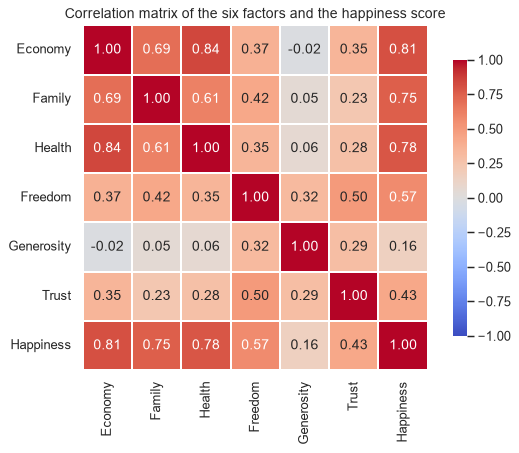

Correlation with the happiness score:
Economy       0.812
Health        0.782
Family        0.753
Freedom       0.570
Trust         0.429
Generosity    0.155


In [8]:
selected = df[FACTORS + ["Happiness.Score"]].copy()
selected.columns = SHORT_NAMES + ["Happiness"]
correlation = selected.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix of the six factors and the happiness score")
plt.tight_layout()
plt.show()

print("Correlation with the happiness score:")
print(correlation["Happiness"].drop("Happiness").sort_values(ascending=False).round(3).to_string())

## Step 7: Strength of the Linear Relationships

**With the score.** Three factors dominate and they are the material ones: `Economy` ($r = 0.81$), `Health` ($0.78$) and `Family` ($0.75$) — all strong. `Freedom` is moderate ($0.57$), `Trust` weak ($0.43$), and `Generosity` is effectively unrelated ($0.16$): generous countries are not systematically happier ones.

**Among the factors.** The strongest pair in the whole matrix is `Economy` ↔ `Health` at $0.84$ — richer countries buy longer lives, and the two carry largely the same information. `Economy` ↔ `Family` ($0.69$) and `Family` ↔ `Health` ($0.61$) follow. This is multicollinearity: the first three factors form one correlated block describing material development, while `Freedom`, `Generosity` and `Trust` are much more loosely connected to it, with `Generosity` nearly orthogonal to everything.

Practically, the six "independent" factors carry closer to three independent directions, which is what makes the clustering below separate countries mostly along a single development axis.

## Step 8: Mapping the Happiness Score

In [9]:
fig = px.choropleth(df,
                    locations="Country",
                    color="Happiness.Score",
                    locationmode="country names",
                    color_continuous_scale="RdYlGn",
                    )
fig.update_layout(title="Happiness Index 2017")
fig.show()

The map shows the familiar geography: Western and Northern Europe, North America and Australasia at the top, Latin America above what their incomes alone would suggest, and Sub-Saharan Africa together with conflict-affected states at the bottom.

## Step 9: Scaling the Features

The six factors live on different ranges — `Family` reaches 1.61 while `Trust` never exceeds 0.46 — and a Gaussian mixture measures distances across all of them at once, so the wider feature would dominate. `data_scale()` offers three options; min-max scaling is used, which maps every factor onto $[0, 1]$ while preserving the shape of its distribution.

In [10]:
def data_scale(data, scaler_type="minmax"):
    """Scale a numeric table with one of three scikit-learn scalers."""
    if scaler_type == "minmax":
        scaler = MinMaxScaler()
    if scaler_type == "std":
        scaler = StandardScaler()
    if scaler_type == "norm":
        scaler = Normalizer()

    scaler.fit(data)
    res = scaler.transform(data)
    return res


original_dataframe = df[FACTORS]

data_scaled = data_scale(original_dataframe)
df_scaled = pd.DataFrame(data_scaled, columns=SHORT_NAMES)
print(df_scaled.head().round(4).to_string())

   Economy  Family  Health  Freedom  Generosity   Trust
0   0.8641  0.9522  0.8390   0.9653      0.4320  0.6805
1   0.7924  0.9631  0.8347   0.9510      0.4239  0.8632
2   0.7915  1.0000  0.8779   0.9528      0.5674  0.3307
3   0.8365  0.9418  0.9038   0.9420      0.3467  0.7904
4   0.7716  0.9563  0.8522   0.9388      0.2929  0.8240


## Step 10: Statistics Before and After Scaling

In [11]:
before = original_dataframe.describe().T[["mean", "std", "min", "max"]]
before.index = SHORT_NAMES
after = df_scaled.describe().T[["mean", "std", "min", "max"]]

comparison = before.join(after, lsuffix=" (original)", rsuffix=" (scaled)")
comparison.round(3)

,mean (original),std (original),min (original),max (original),mean (scaled),std (scaled),min (scaled),max (scaled)
Economy,0.985,0.421,0.0,1.871,0.526,0.225,0.0,1.0
Family,1.189,0.287,0.0,1.611,0.738,0.178,0.0,1.0
Health,0.551,0.237,0.0,0.949,0.581,0.250,0.0,1.0
Freedom,0.409,0.150,0.0,0.658,0.621,0.228,0.0,1.0
Generosity,0.247,0.135,0.0,0.838,0.295,0.161,0.0,1.0
Trust,0.123,0.102,0.0,0.464,0.265,0.219,0.0,1.0


Every feature now runs from exactly 0 to 1, and the ranges that differed by a factor of four (`Family` 1.61 against `Trust` 0.46) are equalized. What scaling does **not** do is make the features equally spread: the standard deviations after scaling still differ almost twofold (`Health` 0.25 against `Generosity` 0.16), because min-max only fixes the endpoints and leaves the shape alone. The means stay unequal for the same reason — `Family` sits at 0.74 of its range while `Trust` sits at 0.27, which is the right-skew seen in Step 5 surviving the transformation unchanged.

Standardization (`scaler_type='std'`) would have equalized means and spreads instead but left the ranges open; for a mixture of Gaussians over bounded scores either is defensible, and min-max keeps the values interpretable as "share of the observed range".

## Step 11: Gaussian Mixture Clustering

A Gaussian mixture describes the data as a weighted sum of normal components and assigns each country the one it most likely came from. Two choices have to be made — how many components, and how much freedom each component's covariance gets — and both can be settled by the Bayesian information criterion, which rewards fit and penalizes parameters.

The clustering uses the **six factors only**. The happiness score stays out, so that comparing the result against it in Step 14 is a real test rather than a tautology.

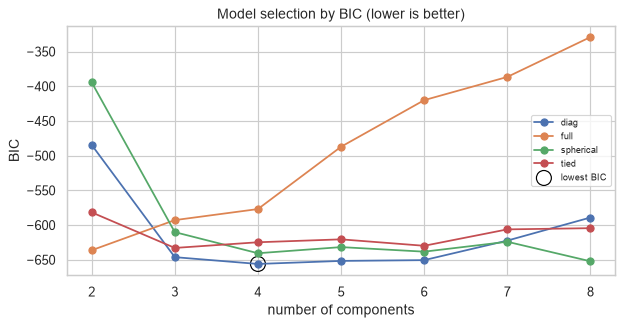

Best model: 4 components, 'diag' covariance, BIC = -656.0


covariance,diag,full,spherical,tied
components,,,,
2,-484.5,-636.3,-394.4,-581.7
3,-646.2,-592.9,-610.2,-633.0
4,-656.0,-576.9,-640.6,-624.8
5,-651.7,-487.2,-631.8,-620.6
6,-650.5,-420.0,-638.3,-629.9
7,-622.4,-386.6,-624.1,-606.2
8,-589.1,-329.1,-652.2,-604.5


In [12]:
X = data_scaled

selection = []
for covariance_type in ("full", "tied", "diag", "spherical"):
    for n_components in range(2, 9):
        model = GaussianMixture(n_components=n_components, covariance_type=covariance_type,
                                random_state=RANDOM_STATE, n_init=10).fit(X)
        selection.append({"covariance": covariance_type, "components": n_components,
                          "BIC": model.bic(X), "AIC": model.aic(X)})

selection = pd.DataFrame(selection)
best = selection.loc[selection["BIC"].idxmin()]

fig, ax = plt.subplots(figsize=(7.5, 4))
for covariance_type, group in selection.groupby("covariance"):
    ax.plot(group["components"], group["BIC"], marker="o", label=covariance_type)
ax.scatter(best["components"], best["BIC"], s=160, facecolors="none", edgecolors="black", label="lowest BIC")
ax.set(title="Model selection by BIC (lower is better)", xlabel="number of components", ylabel="BIC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Best model: {best['components']:.0f} components, '{best['covariance']}' covariance, BIC = {best['BIC']:.1f}")
selection.pivot(index="components", columns="covariance", values="BIC").round(1)

In [13]:
gmm = GaussianMixture(n_components=int(best["components"]), covariance_type=best["covariance"],
                      random_state=RANDOM_STATE, n_init=10).fit(X)

df["cluster"] = gmm.predict(X)
df["cluster_confidence"] = gmm.predict_proba(X).max(axis=1)

profile = df.groupby("cluster").agg(
    countries=("Country", "size"),
    mean_happiness=("Happiness.Score", "mean"),
    mean_rank=("Happiness.Rank", "mean"),
    mean_confidence=("cluster_confidence", "mean"),
).join(df.groupby("cluster")[FACTORS].mean().set_axis(SHORT_NAMES, axis=1))

profile.round(3)

,countries,mean_happiness,mean_rank,mean_confidence,Economy,Family,Health,Freedom,Generosity,Trust
cluster,,,,,,,,,,
0,22,7.004,15.773,0.974,1.534,1.462,0.820,0.584,0.385,0.305
1,42,5.396,75.786,0.933,1.117,1.210,0.662,0.298,0.165,0.059
2,48,5.728,61.646,0.862,1.086,1.331,0.603,0.498,0.252,0.111
3,43,4.051,130.256,0.997,0.461,0.870,0.248,0.328,0.251,0.106


In [14]:
for cluster in sorted(df["cluster"].unique()):
    members = df[df["cluster"] == cluster].sort_values("Happiness.Rank")
    print(f"Cluster {cluster} ({len(members)} countries, mean happiness {members['Happiness.Score'].mean():.2f}):")
    print(f"  top:    {', '.join(members['Country'].head(5))}")
    print(f"  bottom: {', '.join(members['Country'].tail(3))}\n")

Cluster 0 (22 countries, mean happiness 7.00):
  top:    Norway, Denmark, Iceland, Switzerland, Finland
  bottom: Malta, Qatar, Hong Kong S.A.R., China

Cluster 1 (42 countries, mean happiness 5.40):
  top:    Chile, Mexico, Taiwan Province of China, Spain, Slovakia
  bottom: Gabon, Armenia, Ukraine

Cluster 2 (48 countries, mean happiness 5.73):
  top:    Israel, Costa Rica, Brazil, Czech Republic, Argentina
  bottom: Myanmar, Sri Lanka, Botswana

Cluster 3 (43 countries, mean happiness 4.05):
  top:    Pakistan, Somalia, Nigeria, Sierra Leone, Cameroon
  bottom: Tanzania, Burundi, Central African Republic



## Step 12: Mapping the Clusters

In [15]:
df["cluster_label"] = df["cluster"].astype(str)

fig = px.choropleth(df,
                    locations="Country",
                    color="cluster_label",
                    locationmode="country names",
                    hover_data=["Happiness.Rank", "Happiness.Score"],
                    category_orders={"cluster_label": sorted(df["cluster_label"].unique())},
                    )
fig.update_layout(title="GMM clusters of countries by happiness factors, 2017")
fig.show()

## Step 13: The Effect of the Feature Set

The clustering is repeated on four different subsets of the factors, and each result is scored two ways: against the quartiles of the actual happiness score, and against the clustering obtained from all six factors. The Adjusted Rand Index measures agreement between two partitions, where 0 is chance and 1 is identical.

In [16]:
quartiles = pd.qcut(df["Happiness.Score"], 4, labels=False)

FEATURE_SETS = {
    "all six factors": FACTORS,
    "material: economy, health, family": FACTORS[:3],
    "economy alone": FACTORS[:1],
    "institutional: freedom, generosity, trust": FACTORS[3:],
}

experiment = []
for name, columns_subset in FEATURE_SETS.items():
    subset_scaled = data_scale(df[columns_subset])
    labels = GaussianMixture(n_components=int(best["components"]), covariance_type=best["covariance"],
                             random_state=RANDOM_STATE, n_init=10).fit_predict(subset_scaled)

    experiment.append({
        "feature set": name,
        "features": len(columns_subset),
        "ARI vs happiness quartiles": adjusted_rand_score(quartiles, labels),
        "ARI vs the full-set clustering": adjusted_rand_score(df["cluster"], labels),
    })

pd.DataFrame(experiment).round(4)

,feature set,features,ARI vs happiness quartiles,ARI vs the full-set clustering
0,all six factors,6,0.2875,1.0000
1,"material: economy, health, family",3,0.2835,0.3680
2,economy alone,1,0.2366,0.2634
3,"institutional: freedom, generosity, trust",3,0.0743,0.2644


In [17]:
crosstab = pd.crosstab(quartiles, df["cluster"])
crosstab.index = ["Q1 (least happy)", "Q2", "Q3", "Q4 (happiest)"]
crosstab.columns = [f"cluster {c}" for c in crosstab.columns]

print(crosstab.to_string())
print(f"\nARI between the clusters and the happiness quartiles: "
      f"{adjusted_rand_score(quartiles, df['cluster']):.4f}")

                  cluster 0  cluster 1  cluster 2  cluster 3
Q1 (least happy)          0          4          2         33
Q2                        0         17         12         10
Q3                        1         17         20          0
Q4 (happiest)            21          4         14          0

ARI between the clusters and the happiness quartiles: 0.2875


## Step 14: Conclusion

**The clusters recover the happiness ordering without being told it.** Fitted on the six factors alone, the mixture produces four groups whose mean happiness is 7.00, 5.73, 5.40 and 4.05 — a clean ladder, and the extremes are unambiguous: the top cluster is the Nordic and wealthy block (Norway, Denmark, Iceland, Switzerland, Finland), the bottom is Sub-Saharan Africa and conflict-affected states. The agreement with the published quartiles is moderate (ARI 0.29) rather than strong, and the cross-tabulation shows where it holds and where it does not: the least happy quartile lands almost entirely in one cluster (33 of 39) and no country from the two bottom quartiles reaches cluster 0, but the happiest quartile is divided between clusters 0 and 2, and the middle two are spread across three clusters each.

**The middle is split along a different axis.** Clusters 1 and 2 have nearly identical economies (1.12 against 1.09) and differ mainly in freedom (0.30 against 0.50) and trust (0.06 against 0.11). The model has found a real distinction that the happiness score averages away — countries of similar wealth but very different institutional quality. That is a feature of unsupervised learning, not a failure: it groups by the shape of the whole profile, not by the one number.

**Material factors carry the structure.** Clustering on economy, health and family alone reproduces nearly the same agreement with the ranking (ARI 0.28 against 0.29) while using half the features, and economy alone still reaches 0.24. The three institutional factors on their own collapse to 0.07 — barely above chance. This matches the correlation matrix from Step 7: the material block is one strong direction, and most of the separation between countries lies along it.